# Biodiversity Portfolio Project

## Preparation

### Import necessary libraries

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read in the data

In [2]:
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

## Exploration

### Look at first rows of dfs

In [3]:
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [4]:
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


### Descriptive statistis of dfs

In [5]:
species.describe(include='all')

,category,scientific_name,common_names,conservation_status
count,5824,5824,5824,191
unique,7,5541,5504,4
top,Vascular Plant,Castor canadensis,Brachythecium Moss,Species of Concern
freq,4470,3,7,161


In [6]:
species.shape

(5824, 4)

In [7]:
print(observations.isnull().sum())

scientific_name    0
park_name          0
observations       0
dtype: int64


In [8]:
observations.describe(include='all')

,scientific_name,park_name,observations
count,23296,23296,23296.000000
unique,5541,4,NaN
top,Myotis lucifugus,Great Smoky Mountains National Park,NaN
freq,12,5824,NaN
mean,NaN,NaN,142.287904
std,NaN,NaN,69.890532
min,NaN,NaN,9.000000
25%,NaN,NaN,86.000000
50%,NaN,NaN,124.000000
75%,NaN,NaN,195.000000


In [9]:
print(species.isnull().sum())

category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64


In [10]:
observations.shape

(23296, 3)

## Print unique values

In [11]:
for col in species.select_dtypes(include=['object', 'category']):
    print(f'{col}:\n{species[col].value_counts()}\n')

category:
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: category, dtype: int64

scientific_name:
Castor canadensis            3
Canis lupus                  3
Hypochaeris radicata         3
Columba livia                3
Puma concolor                3
                            ..
Carex                        1
Hexastylis shuttleworthii    1
Hexastylis heterophylla      1
Hexastylis arifolia          1
Tribulus terrestris          1
Name: scientific_name, Length: 5541, dtype: int64

common_names:
Brachythecium Moss                                                            7
Dicranum Moss                                                                 7
Panic Grass                                                                   6
Bryum Moss                                                                    6
Sphagnum                           

In [12]:
for col in observations.select_dtypes(include=['object', 'category']):
    print(f'{col}:\n{observations[col].value_counts()}\n')

scientific_name:
Myotis lucifugus                        12
Puma concolor                           12
Hypochaeris radicata                    12
Holcus lanatus                          12
Streptopelia decaocto                   12
                                        ..
Packera dimorphophylla var. paysonii     4
Smilax bona-nox                          4
Chondestes grammacus                     4
Leymus triticoides                       4
Dichanthelium depauperatum               4
Name: scientific_name, Length: 5541, dtype: int64

park_name:
Great Smoky Mountains National Park    5824
Yosemite National Park                 5824
Bryce National Park                    5824
Yellowstone National Park              5824
Name: park_name, dtype: int64



### Conclusion
- both dfs share the same column "scientific_name"
- df "species" contains more information about species like class and conservation
- df "observations" shows observations of species in each national park
- conservation status contains a lot of missing values

## Analyze: distribution of conservation status for animals

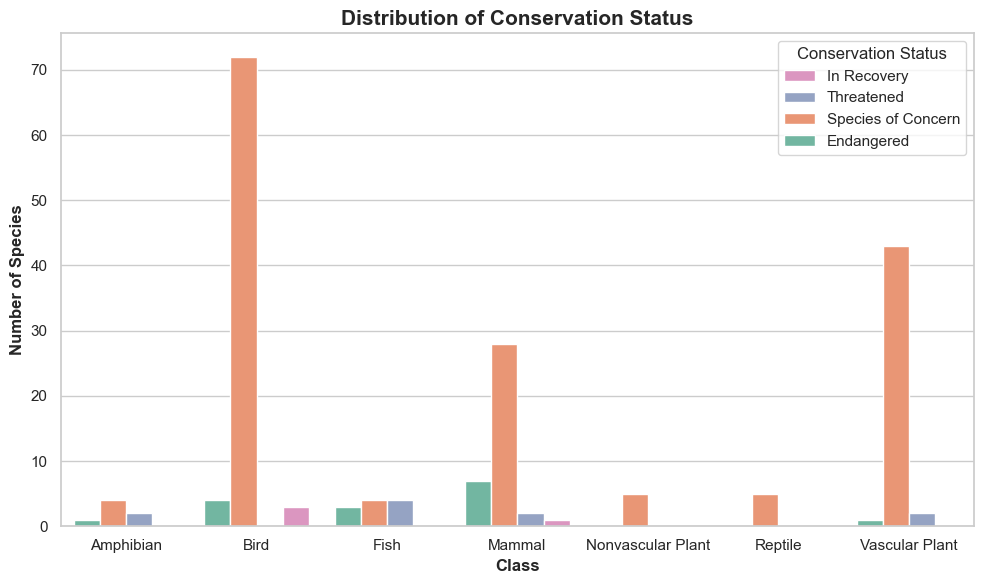

<Figure size 640x480 with 0 Axes>

In [13]:
#group species based on species class (category) and its conservation status, add a count for each combination
species_grouped = species.groupby(["category", "conservation_status"]).size().reset_index(name="count")

#plot the barplot with species class on x-axis, count for each combination on y-axis, and the conservation status in the legend
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=species_grouped,
    x="category",
    y="count",
    hue="conservation_status",
    palette="Set2"
)

#set labels and titles, show plot
plt.xlabel("Class", fontweight = "bold")
plt.ylabel("Number of Species", fontweight = "bold")
plt.title("Distribution of Conservation Status", fontsize=15, fontweight = "bold" )
plt.legend(title= "Conservation Status", reverse = True)
plt.tight_layout()
plt.show()
plt.clf()

### Conclusion
- For all classes of species the most common conservation status is "Species of Concern"
- Overall species numbers vary strongly from class to class
- All Nonvascular Plants and Reptiles are Species of Concern (at least visibly on the figure)

## Analyze: Endangered Species

In [14]:
#create sub-df with only endangered species
species_endangered = species[species["conservation_status"] == "Endangered"]
species_endangered.head()

,category,scientific_name,common_names,conservation_status
8,Mammal,Canis lupus,Gray Wolf,Endangered
9,Mammal,Canis rufus,Red Wolf,Endangered
34,Mammal,Myotis grisescens,Gray Myotis,Endangered
39,Mammal,Myotis sodalis,"Indiana Bat, Indiana Or Social Myotis",Endangered
72,Mammal,Glaucomys sabrinus coloratus,"Carolina Northern Flying Squirrel, Northern Fl...",Endangered


/var/folders/bl/078b9fj93sndfyd7tn__qsqr0000gn/T/ipykernel_1543/3495375125.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bl/078b9fj93sndfyd7tn__qsqr0000gn/T/ipykernel_1543/3495375125.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title= "Class", reverse = True)


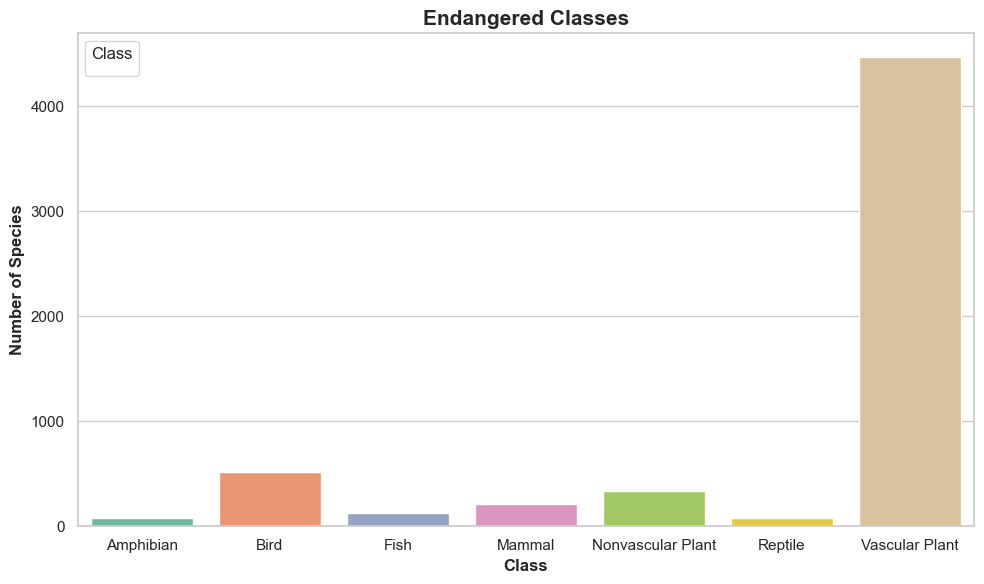

<Figure size 640x480 with 0 Axes>

In [15]:
#group subdf by species name and add count for each combination
species_endangered_grouped = species.groupby(["category"]).size().reset_index(name="count")

#plot the barplot with species name on x-axis, count for each combination on y-axis
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=species_endangered_grouped,
    x="category",
    y="count",
    palette="Set2"
)

#set labels and titles, show plot
plt.xlabel("Class", fontweight = "bold")
plt.ylabel("Number of Species", fontweight = "bold")
plt.title("Endangered Classes", fontsize=15, fontweight = "bold" )
plt.legend(title= "Class", reverse = True)
plt.tight_layout()
plt.show()
plt.clf()

## Analyze: Differences between Endangered Species

In [16]:
species_endangered_grouped.head()

,category,count
0,Amphibian,80
1,Bird,521
2,Fish,127
3,Mammal,214
4,Nonvascular Plant,333


In [17]:
#conduct chi-square on counts for different classes of species
observed_counts = species_endangered_grouped["count"]
chi2, p = stats.chisquare(observed_counts)

print(f"Chi-square statistic: {chi2}, p-value: {p}")

Chi-square statistic: 18740.658653846156, p-value: 0.0


### Conclusion
- Vascular Plants have the highest number of endangered species
- Amphibian and reptiles have the lowest number of endagered species
- Differences between species classes are highly significact

## Analyze: Most spotted Species at each Park

In [18]:
#merge the dfs based on the scienific name of the species
species_observations = species.merge(observations, on="scientific_name", how="outer")
species_observations.head()

,category,scientific_name,common_names,conservation_status,park_name,observations
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN,Bryce National Park,130
1,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN,Yellowstone National Park,270
2,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN,Great Smoky Mountains National Park,98
3,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN,Yosemite National Park,117
4,Mammal,Bos bison,"American Bison, Bison",NaN,Yosemite National Park,128


In [19]:
#group the merged d based on the scientific species name and name of the national park
species_observations_grouped = species_observations.groupby(["scientific_name", "park_name"]).observations.sum().reset_index()
species_observations_grouped.head()

,scientific_name,park_name,observations
0,Abies bifolia,Bryce National Park,109
1,Abies bifolia,Great Smoky Mountains National Park,72
2,Abies bifolia,Yellowstone National Park,215
3,Abies bifolia,Yosemite National Park,136
4,Abies concolor,Bryce National Park,83


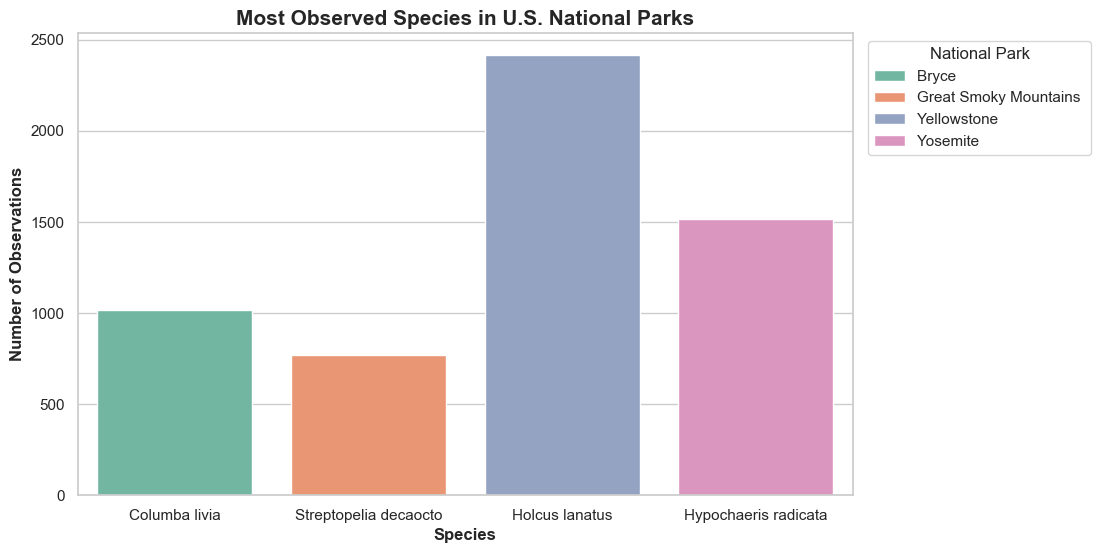

<Figure size 640x480 with 0 Axes>

In [20]:
#extract rows with the maximum value of observations of species for each national park
max_values_observations = species_observations_grouped.loc[species_observations_grouped.groupby('park_name')['observations'].idxmax()].reset_index()

#plot the barplot with species name on x-axis, number of observations on y-axis and national park name in the legend
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=max_values_observations,
    x="scientific_name",
    y="observations",
    hue = "park_name",
    palette="Set2"
)

#set labels and titles, show plot
handles, labels = ax.get_legend_handles_labels()
new_labels = [label.replace("National Park", "") for label in labels]
ax.legend(handles=handles, labels=new_labels, title="National Park", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_xlabel("Species", fontweight = "bold")
ax.set_ylabel("Number of Observations", fontweight = "bold")
ax.set_title("Most Observed Species in U.S. National Parks", fontsize = 15, fontweight = "bold")
plt.show()
plt.clf()

### Conclusion
- "Holcus lanatus" is the most overall observed species
- Each national park has another most observed species